<a href="https://colab.research.google.com/github/RuiRodrigues-lab/DataScienceFE/blob/Locker/CP4_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
#Precisamos desta biblioteca para podermos escolher um ficheiro local
#Se o ficheiro vier por API ou tivermos um link, é so alterar a forma de import
from google.colab import files

# 1️⃣ Faz upload do ficheiro (vai abrir uma janela para escolher no teu PC)
uploaded = files.upload()

# 2️⃣ Guarda o nome do ficheiro (Colab mostra o nome depois do upload)
filename = list(uploaded.keys())[0]

# 3️⃣ Lê o Excel, por default lê sempre a primeira tab, por isso podemos usar o "sheet_name"
# Se tivermos dados em varias tabs, devemos usar uma Dataframe(df) para cada uma das tabs
df = pd.read_excel(filename, sheet_name='Exerc3')
df.head()


Saving CP4_3.xlsx to CP4_3.xlsx


,Click,Email
0,Clicou,Promocional
1,Clicou,Promocional
2,Clicou,Promocional
3,Clicou,Promocional
4,Clicou,Promocional


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Click   200 non-null    object
 1   Email   200 non-null    object
dtypes: object(2)
memory usage: 3.3+ KB


In [3]:
# 4️⃣ Converter para factores (ambas qualitativas nominais, por isso não precisam ser ordenadas)
df['Click'] = df['Click'].astype('category')
df['Email'] = df['Email'].astype('category')

# 5️⃣ Tabelas de contingência
tab = pd.crosstab(df['Email'], df['Click'])
print("\n📊 Tabela de Contingência:")
print(tab)


📊 Tabela de Contingência:
Click        Clicou  Não clicou
Email                          
Informativo      20          80
Promocional      25          75


In [4]:
# 6️⃣ Proporções (% do total)
prop_total = pd.crosstab(df['Email'], df['Click'], normalize='all') * 100
print("\n📊 Proporções (%) sobre o total:")
print(prop_total.round(1))


📊 Proporções (%) sobre o total:
Click        Clicou  Não clicou
Email                          
Informativo    10.0        40.0
Promocional    12.5        37.5


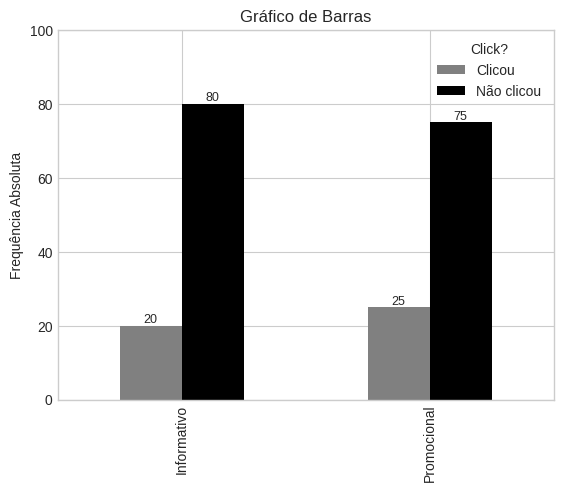

In [9]:
# --------------------------------------------------
# 5️⃣ Gráficos
# --------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
cores = ["gray", "black"]


# --------------------------------------------------
# G1 — Barras lado a lado
# --------------------------------------------------
ax = tab.plot(kind='bar', color=cores)
plt.title("Gráfico de Barras")
plt.ylabel("Frequência Absoluta")
plt.xlabel("")
plt.ylim(0, 100)
plt.legend(title="Click?", loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9)
plt.show()

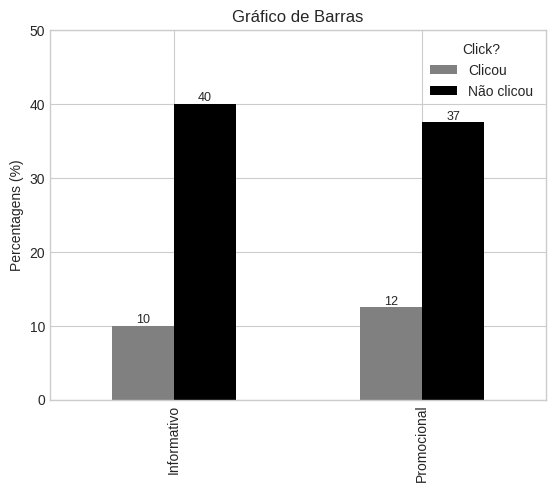

In [12]:
# --------------------------------------------------
# G2 — Barras lado a lado
# --------------------------------------------------
ax = prop_total.plot(kind='bar', color=cores)
plt.title("Gráfico de Barras")
plt.ylabel("Percentagens (%)")
plt.xlabel("")
plt.ylim(0, 50)
plt.legend(title="Click?", loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9)
plt.show()